In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/Others/T10YIE.csv'

# Read the CSV file with low_memory set to False
data = pd.read_csv(file_path, low_memory=False)

# View the first few rows of the dataframe
data.head()

,DATE,T10YIE
0,2019-11-22,1.62
1,2019-11-25,1.62
2,2019-11-26,1.62
3,2019-11-27,1.63
4,2019-11-28,.


In [ ]:
data['DATE'] = pd.to_datetime(data['DATE'])
data['T10YIE'] = pd.to_numeric(data['T10YIE'], errors='coerce')
data_cleaned = data.dropna()

In [ ]:
# Feature engineering: Create lagged features
def create_lagged_features(df, target_col, lags=5):
    df = df.copy()
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    df['rolling_mean'] = df[target_col].rolling(window=lags).mean()
    df.dropna(inplace=True)
    return df

data_cleaned = create_lagged_features(data_cleaned, target_col='T10YIE', lags=5)

In [ ]:
# Train-test split
X = data_cleaned.drop(columns=['DATE', 'T10YIE'])
y = data_cleaned['T10YIE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# Helper function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results.append({'Model': model_name, 'MSE': mse, 'R2': r2})
    return mse, r2

In [ ]:
# Store results
results = []

In [ ]:
# MACHINE LEARNING MODELS
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
evaluate_model(y_test, rf_pred, "Random Forest")

(0.0005613865200000002, 0.9325606881886928)

In [ ]:
# XGBoost
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
evaluate_model(y_test, xgb_pred, "XGBoost")

(0.0005953013512298912, 0.9284865025841996)

In [ ]:
# CatBoost
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)
evaluate_model(y_test, cat_pred, "CatBoost")

(0.0005421097502301057, 0.9348764047955445)

In [ ]:
# Support Vector Regression
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)
svr_pred = svr_model.predict(X_test)
evaluate_model(y_test, svr_pred, "SVR")

(0.0005924880798598764, 0.928824460619124)

In [ ]:
# DEEP LEARNING MODELS
def reshape_for_rnn(X):
    return X.values.reshape((X.shape[0], X.shape[1], 1))

X_train_rnn = reshape_for_rnn(X_train)
X_test_rnn = reshape_for_rnn(X_test)

In [ ]:
# LSTM
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
lstm_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test_rnn).flatten()
evaluate_model(y_test, lstm_pred, "LSTM")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


(0.000553573003241927, 0.9334993252492879)

In [ ]:
# GRU
gru_model = Sequential([
    GRU(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
    Dense(1)
])
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
gru_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
gru_pred = gru_model.predict(X_test_rnn).flatten()
evaluate_model(y_test, gru_pred, "GRU")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


(0.000750381733573676, 0.9098567102965273)

In [ ]:
# Bidirectional LSTM
bi_lstm_model = Sequential([
    Bidirectional(LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1))),
    Dense(1)
])
bi_lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
bi_lstm_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
bi_lstm_pred = bi_lstm_model.predict(X_test_rnn).flatten()
evaluate_model(y_test, bi_lstm_pred, "Bidirectional LSTM")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


(0.0003640821636863895, 0.9562628426457731)

In [ ]:
# Bidirectional GRU
bi_gru_model = Sequential([
    Bidirectional(GRU(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1))),
    Dense(1)
])
bi_gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
bi_gru_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
bi_gru_pred = bi_gru_model.predict(X_test_rnn).flatten()
evaluate_model(y_test, bi_gru_pred, "Bidirectional GRU")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


(0.00024199907530547517, 0.9709286729977521)

In [ ]:
# CNN
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(1)
])
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
cnn_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
cnn_pred = cnn_model.predict(X_test_rnn).flatten()
evaluate_model(y_test, cnn_pred, "1D CNN")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


(0.001239237576224624, 0.8511305021871544)

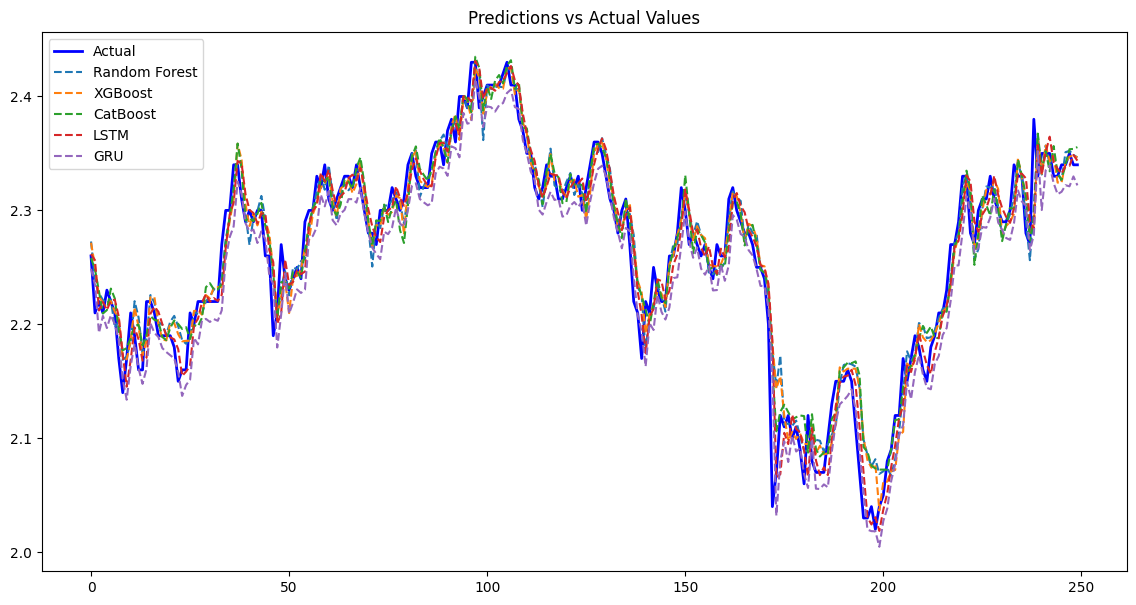

In [ ]:
# Plot predictions for all models
plt.figure(figsize=(14, 7))
plt.plot(y_test.values, label='Actual', color='blue', linewidth=2)
plt.plot(rf_pred, label='Random Forest', linestyle='--')
plt.plot(xgb_pred, label='XGBoost', linestyle='--')
plt.plot(cat_pred, label='CatBoost', linestyle='--')
plt.plot(lstm_pred, label='LSTM', linestyle='--')
plt.plot(gru_pred, label='GRU', linestyle='--')
plt.legend()
plt.title("Predictions vs Actual Values")
plt.show()

In [ ]:
# Display results summary
results_df = pd.DataFrame(results)
print(results_df)

                Model       MSE        R2
0       Random Forest  0.000561  0.932561
1             XGBoost  0.000595  0.928487
2            CatBoost  0.000542  0.934876
3                 SVR  0.000592  0.928824
4                LSTM  0.000554  0.933499
5                 GRU  0.000750  0.909857
6  Bidirectional LSTM  0.000364  0.956263
7   Bidirectional GRU  0.000242  0.970929
8              1D CNN  0.001239  0.851131


In [ ]:
# HYBRID MODELS
# Machine Learning + Deep Learning

# Random Forest + LSTM
def random_forest_lstm():
    # Step 1: Train Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_pred_train = rf_model.predict(X_train)
    rf_pred_test = rf_model.predict(X_test)

    # Step 2: Train LSTM on residuals
    residuals_train = y_train - rf_pred_train
    residuals_test = y_test - rf_pred_test

    lstm_model = Sequential([
        LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
        Dense(1)
    ])
    lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    lstm_model.fit(X_train_rnn, residuals_train, epochs=1000, batch_size=32, verbose=0)

    lstm_pred_residuals = lstm_model.predict(X_test_rnn).flatten()
    final_predictions = rf_pred_test + lstm_pred_residuals

    evaluate_model(y_test, final_predictions, "Random Forest + LSTM")

random_forest_lstm()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [ ]:

# XGBoost + GRU
def xgboost_gru():
    # Step 1: Train XGBoost
    xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, random_state=42)
    xgb_model.fit(X_train, y_train)
    xgb_pred_train = xgb_model.predict(X_train)
    xgb_pred_test = xgb_model.predict(X_test)

    # Step 2: Train GRU on residuals
    residuals_train = y_train - xgb_pred_train

    gru_model = Sequential([
        GRU(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
        Dense(1)
    ])
    gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    gru_model.fit(X_train_rnn, residuals_train, epochs=1000, batch_size=32, verbose=0)

    gru_pred_residuals = gru_model.predict(X_test_rnn).flatten()
    final_predictions = xgb_pred_test + gru_pred_residuals

    evaluate_model(y_test, final_predictions, "XGBoost + GRU")

xgboost_gru()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [ ]:

# CatBoost + Bidirectional LSTM
def catboost_bilstm():
    # Step 1: Train CatBoost
    cat_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42)
    cat_model.fit(X_train, y_train)
    cat_pred_train = cat_model.predict(X_train)
    cat_pred_test = cat_model.predict(X_test)

    # Step 2: Train Bidirectional LSTM on residuals
    residuals_train = y_train - cat_pred_train

    bi_lstm_model = Sequential([
        Bidirectional(LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], 1))),
        Dense(1)
    ])
    bi_lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    bi_lstm_model.fit(X_train_rnn, residuals_train, epochs=1000, batch_size=32, verbose=0)

    bi_lstm_pred_residuals = bi_lstm_model.predict(X_test_rnn).flatten()
    final_predictions = cat_pred_test + bi_lstm_pred_residuals

    evaluate_model(y_test, final_predictions, "CatBoost + Bidirectional LSTM")

catboost_bilstm()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


In [ ]:
# Deep Learning + Deep Learning

# LSTM + CNN
def lstm_cnn():
    lstm_cnn_model = Sequential([
        LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)),
        Conv1D(filters=64, kernel_size=2, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(1)
    ])
    lstm_cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    lstm_cnn_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
    lstm_cnn_pred = lstm_cnn_model.predict(X_test_rnn).flatten()

    evaluate_model(y_test, lstm_cnn_pred, "LSTM + CNN")

lstm_cnn()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [ ]:
# Bidirectional GRU + CNN
def bidirectional_gru_cnn():
    bi_gru_cnn_model = Sequential([
        Bidirectional(GRU(50, activation='relu', return_sequences=True, input_shape=(X_train_rnn.shape[1], 1))),
        Conv1D(filters=64, kernel_size=2, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(1)
    ])
    bi_gru_cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    bi_gru_cnn_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
    bi_gru_cnn_pred = bi_gru_cnn_model.predict(X_test_rnn).flatten()

    evaluate_model(y_test, bi_gru_cnn_pred, "Bidirectional GRU + CNN")

bidirectional_gru_cnn()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


In [ ]:
# Stacked LSTM + GRU
def stacked_lstm_gru():
    lstm_gru_model = Sequential([
        LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)),
        GRU(50, activation='relu', return_sequences=False),
        Dense(1)
    ])
    lstm_gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    lstm_gru_model.fit(X_train_rnn, y_train, epochs=1000, batch_size=32, verbose=0)
    lstm_gru_pred = lstm_gru_model.predict(X_test_rnn).flatten()

    evaluate_model(y_test, lstm_gru_pred, "Stacked LSTM + GRU")

stacked_lstm_gru()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [ ]:
#Machine Learning + Machine Learning

# XGBoost + Random Forest
def xgboost_random_forest():
    # Step 1: Train XGBoost
    xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, random_state=42)
    xgb_model.fit(X_train, y_train)
    xgb_pred_train = xgb_model.predict(X_train)

    # Step 2: Train Random Forest on XGBoost predictions
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train.assign(xgb_pred=xgb_pred_train), y_train)

    # Combine XGBoost predictions with Random Forest
    xgb_rf_pred = rf_model.predict(X_test.assign(xgb_pred=xgb_model.predict(X_test)))

    evaluate_model(y_test, xgb_rf_pred, "XGBoost + Random Forest")

xgboost_random_forest()

In [ ]:

# CatBoost + Support Vector Regression (SVR)
def catboost_svr():
    # Step 1: Train CatBoost
    cat_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42)
    cat_model.fit(X_train, y_train)
    cat_pred_train = cat_model.predict(X_train)

    # Step 2: Train SVR on CatBoost predictions
    svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
    svr_model.fit(X_train.assign(cat_pred=cat_pred_train), y_train)

    # Combine CatBoost predictions with SVR
    cat_svr_pred = svr_model.predict(X_test.assign(cat_pred=cat_model.predict(X_test)))

    evaluate_model(y_test, cat_svr_pred, "CatBoost + SVR")

catboost_svr()


In [ ]:
# Ensemble Models

# Model Averaging
def model_averaging():
    predictions = [rf_pred, xgb_pred, cat_pred, lstm_pred]
    avg_predictions = np.mean(predictions, axis=0)
    evaluate_model(y_test, avg_predictions, "Model Averaging")

model_averaging()


In [ ]:
# Stacking
from sklearn.ensemble import StackingRegressor

def stacking():
    base_models = [
        ('random_forest', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('xgboost', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)),
        ('catboost', CatBoostRegressor(iterations=100, learning_rate=0.1, depth=5, verbose=0, random_state=42)),
        ('svr', SVR(kernel='rbf', C=100, epsilon=0.1))
    ]
    meta_model = RandomForestRegressor(n_estimators=50, random_state=42)

    stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)
    stacking_model.fit(X_train, y_train)
    stacking_pred = stacking_model.predict(X_test)

    evaluate_model(y_test, stacking_pred, "Stacking")

stacking()

In [ ]:
# Summary Table
results_df = pd.DataFrame(results)
print(results_df)

                            Model       MSE        R2
0                   Random Forest  0.000561  0.932561
1                         XGBoost  0.000595  0.928487
2                        CatBoost  0.000542  0.934876
3                             SVR  0.000592  0.928824
4                            LSTM  0.000554  0.933499
5                             GRU  0.000750  0.909857
6              Bidirectional LSTM  0.000364  0.956263
7               Bidirectional GRU  0.000242  0.970929
8                          1D CNN  0.001239  0.851131
9            Random Forest + LSTM  0.000462  0.944459
10                  XGBoost + GRU  0.000348  0.958146
11  CatBoost + Bidirectional LSTM  0.000403  0.951587
12                     LSTM + CNN  0.001299  0.843974
13        Bidirectional GRU + CNN  0.000271  0.967407
14             Stacked LSTM + GRU  0.000879  0.894357
15        XGBoost + Random Forest  0.000536  0.935652
16                 CatBoost + SVR  0.000749  0.909966
17                Model Aver